# Module 2.1 — Market Microstructure
## Understanding How Markets Actually Work

---

### The Foundation of Modern Trading

Market microstructure is the study of **how markets actually operate at the most granular level**. While traditional finance focuses on asset pricing and portfolio theory, microstructure examines the **mechanics of price formation, order execution, and market liquidity**. This is not an academic curiosity—it is the operational reality that determines whether your trading strategy succeeds or fails in live markets. Every trade you execute interacts with the microstructure: order books, bid-ask spreads, market makers, and execution algorithms. Understanding these mechanics is the difference between a strategy that looks profitable in backtests but bleeds money in production, and one that actually captures the edge you've identified.

The revolution in electronic trading has made microstructure knowledge non-optional for quantitative traders. In the era of high-frequency trading, dark pools, and algorithmic execution, the **transaction costs** embedded in market microstructure can completely dominate your returns. A strategy with an expected return of 10 basis points per trade can be rendered unprofitable by 15 basis points of slippage and market impact. Professional traders spend as much time optimizing execution as they do finding alpha. This module builds your intuition for how orders become trades, how prices move in response to order flow, and how to minimize the implicit costs that separate theoretical returns from realized P&L.

---

### Learning Objectives

By the end of this module, you will:

1. **Master order types** and their strategic uses (market, limit, stop, iceberg orders)
2. **Understand order book dynamics** and how prices form from supply and demand
3. **Calculate and interpret** bid-ask spreads, effective spreads, and realized spreads
4. **Quantify market impact** and how your orders move prices against you
5. **Distinguish** market makers from takers and their different economics
6. **Analyze** high-frequency trading strategies and their market impact
7. **Evaluate** dark pools and alternative trading venues
8. **Simulate** order book dynamics and execution scenarios

---

### Module Contents

1. **Order Types & Mechanics** — The building blocks of trading
2. **Order Book Structure** — How markets organize supply and demand
3. **Bid-Ask Spread** — The cost of immediacy
4. **Market Impact** — How your orders move prices
5. **Market Makers vs. Takers** — The economics of liquidity provision
6. **High-Frequency Trading** — Speed, latency, and edge
7. **Dark Pools & Alternative Venues** — Trading in the shadows
8. **Practical Execution Strategies** — Minimizing transaction costs

---

*"In theory, there is no difference between theory and practice. In practice, there is." — Yogi Berra*

*Market microstructure is where theory meets practice.*

In [6]:
# ========================================
# Initial Setup and Configuration
# ========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from typing import List, Dict, Tuple, Optional, Any
from dataclasses import dataclass, field
from enum import Enum
import warnings
from datetime import datetime, timedelta
from collections import deque
import heapq

warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Configure plotting aesthetics
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Enhanced plot configuration
PLOT_CONFIG = {
    'figure.figsize': (14, 7),
    'axes.titlesize': 16,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.dpi': 100,
    'lines.linewidth': 2,
}
plt.rcParams.update(PLOT_CONFIG)

# Color scheme for visualizations
COLORS = {
    'bid': '#2E7D32',      # Dark green for bids
    'ask': '#C62828',      # Dark red for asks
    'trade': '#1565C0',    # Blue for trades
    'spread': '#F57C00',   # Orange for spreads
    'impact': '#6A1B9A',   # Purple for market impact
    'neutral': '#455A64',  # Gray for neutral elements
}

print("="*80)
print(" " * 20 + "MODULE 2.1: MARKET MICROSTRUCTURE")
print("="*80)
print(f"✓ Environment configured successfully")
print(f"✓ Random seed: {RANDOM_SEED}")
print(f"✓ NumPy version: {np.__version__}")
print(f"✓ Pandas version: {pd.__version__}")
print(f"✓ Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)
print("\n📚 Ready to explore how markets actually work!\n")

                    MODULE 2.1: MARKET MICROSTRUCTURE
✓ Environment configured successfully
✓ Random seed: 42
✓ NumPy version: 2.3.5
✓ Pandas version: 2.3.3
✓ Timestamp: 2026-03-13 22:43:30

📚 Ready to explore how markets actually work!



---

## 1. Order Types and Mechanics

### 1.1 Market Orders: Trading with Certainty of Execution

A **market order** is an instruction to buy or sell immediately at the best available current price. Market orders prioritize **execution certainty over price certainty**. When you submit a market buy order, you are saying "I want to own this asset right now, and I'm willing to pay whatever the current sellers are asking." This guarantee of execution comes at a cost: you cross the bid-ask spread and potentially suffer slippage if your order size exceeds the available liquidity at the best price level. Market orders are the weapons of urgency—used when the information edge is perishable, when you need to exit a position immediately due to risk management, or when the cost of non-execution exceeds the cost of crossing the spread.

The danger of market orders lies in their interaction with the order book during periods of low liquidity or high volatility. A large market order can "walk up the book," executing at progressively worse prices as it exhausts liquidity at each price level. This phenomenon, called **market impact**, can be devastating for large trades. Consider a market buy order for 10,000 shares when only 1,000 shares are offered at the best ask price of $100.00. The order will consume those 1,000 shares, then move to the next level at $100.05, then perhaps $100.10, and so on. Your average execution price might be $100.15, even though you thought you were buying at $100.00. This is why professional traders rarely use market orders for large sizes—instead, they use algorithms to slice the order into smaller pieces and execute over time.

### 1.2 Limit Orders: Trading with Price Control

A **limit order** specifies the maximum price you're willing to pay (for a buy) or the minimum price you'll accept (for a sell). Unlike market orders, limit orders prioritize **price certainty over execution certainty**. A limit buy order at $99.50 will only execute if the market price falls to $99.50 or below. This gives you price protection but introduces execution risk—your order might never fill, and you could miss the trade entirely. Limit orders are the building blocks of the order book itself: all the resting bids and asks you see in the book are limit orders waiting for counterparties. When you place a limit order that doesn't immediately execute, you become a **liquidity provider**, offering to trade at your specified price and often receiving a rebate from the exchange for adding liquidity.

The strategic use of limit orders requires understanding the **queue priority** system. Most exchanges use price-time priority: orders at the same price level are filled in the sequence they arrived. If there are 5,000 shares bid at $99.50 and you add a bid for 1,000 shares at the same price, you go to the back of the queue. You'll only get filled after the first 5,000 shares trade. This creates interesting dynamics around "pennying"—placing your order one penny better than existing orders to jump to the front of the queue. However, this can lead to a race where everyone pennies each other, ultimately widening the spread. Sophisticated traders use limit orders as **options on future price movements**: a resting limit order is like a free option that executes if the price moves in your favor. If you place a limit sell at $101.00 and the market rallies to $101.50, your order executes at $101.00, capturing the move. But if the price stays at $100.00, your order never fills, and you've lost nothing except the opportunity cost.

### 1.3 Stop Orders: Automated Risk Management

A **stop order** (or stop-loss order) becomes a market order once a specified trigger price is reached. Stop orders are primarily used for **risk management and breakout trading**. A trader who buys a stock at $100.00 might place a stop-loss sell order at $95.00 to limit downside risk. If the price falls to $95.00, the stop order triggers and becomes a market sell order, (hopefully) limiting the loss to $5 per share. The critical word is "hopefully" because stop orders offer no price guarantee once triggered—in a fast-moving market, the actual execution price can be significantly worse than the stop price. This is called **slippage**, and it can be severe during flash crashes or gaps (when the market opens significantly away from the previous close).

Stop orders also play a role in momentum and breakout strategies. A **stop-buy order** at $105.00 will trigger a buy if the price rises to that level, allowing traders to enter positions as momentum builds. However, clusters of stop orders create dangerous feedback loops. If many traders have stop-losses at the same price level (say, just below a major support level at $95.00), a temporary dip below $95.00 can trigger a cascade of selling as all the stops execute simultaneously, driving the price even lower. This phenomenon is called a **stop run** or **liquidity grab**, and sophisticated traders actively hunt for these clusters. High-frequency traders can even probe the order book to discover where stops are hidden, then trigger them to profit from the ensuing volatility. The professional solution is to use **stop-limit orders** (which become limit orders rather than market orders when triggered) or to avoid placing stops at obvious technical levels where everyone else has them.

### 1.4 Iceberg Orders: Hiding Your Intentions

An **iceberg order** (also called a hidden order or reserve order) displays only a small portion of the total order size in the public order book, keeping the remainder hidden. If you want to buy 100,000 shares but only show 1,000 shares at a time, you use an iceberg order. As the visible portion gets filled, the exchange automatically replenishes it from the hidden reserve, maintaining the 1,000-share display until the entire 100,000 shares are executed. Iceberg orders are essential for **information hiding**—they prevent other market participants from learning your true intentions and trading size. If other traders see a 100,000-share bid in the book, they might front-run you, buying ahead of your order in anticipation that your large size will push prices higher.

The downside of iceberg orders is the **queue priority penalty**. Each time the visible portion is replenished, it goes to the back of the queue at that price level, even though the order has been resting in the book. This means an iceberg order at $100.00 might get executed after regular limit orders that arrived later but are fully visible. Additionally, sophisticated traders use **iceberg detection algorithms** that watch for patterns of replenishment and can infer the presence of hidden size. They look for repeated fills at the same price level with suspiciously consistent size, or for resilience in the order book after large trades (which suggests hidden orders are being replenished). Once detected, your iceberg order loses its stealth advantage. Modern execution algorithms address this by varying the displayed size, using multiple price levels, and spreading orders across different venues to make detection harder. Despite these limitations, iceberg orders remain a crucial tool for institutional traders who need to execute large blocks without advertising their intentions to the entire market.

---

### Mathematical Framework for Order Execution

**Market Order Execution Price**:

For a market buy order of size $Q$, the average execution price $\bar{P}$ is:

$$\bar{P} = \frac{1}{Q} \sum_{i=1}^{n} q_i p_i$$

where $q_i$ is the quantity filled at price level $p_i$, and $\sum_{i=1}^{n} q_i = Q$.

**Limit Order Fill Probability**:

The probability that a limit order at price $p_L$ fills within time $T$ is approximately:

$$\mathbb{P}(\text{Fill}) = \mathbb{P}(P_t \leq p_L) \cdot \mathbb{P}(\text{Queue clears})$$

where $P_t$ is the market price at time $t$ and queue clearing depends on order flow.

**Stop Order Slippage**:

Expected slippage for a stop order with trigger $p_s$ is:

$$\text{Slippage} = \mathbb{E}[P_{\text{exec}} - p_s | P_t = p_s]$$

This depends on market depth, volatility, and order size.

In [2]:
# ========================================
# Order Type Definitions and Simulation
# ========================================

class OrderType(Enum):
    """Enumeration of order types."""
    MARKET = "market"
    LIMIT = "limit"
    STOP = "stop"
    STOP_LIMIT = "stop_limit"
    ICEBERG = "iceberg"

class OrderSide(Enum):
    """Order side: buy or sell."""
    BUY = "buy"
    SELL = "sell"

@dataclass
class Order:
    """Representation of a trading order."""
    order_id: int
    order_type: OrderType
    side: OrderSide
    quantity: int
    price: Optional[float] = None  # None for market orders
    stop_price: Optional[float] = None  # For stop orders
    visible_quantity: Optional[int] = None  # For iceberg orders
    timestamp: datetime = field(default_factory=datetime.now)
    filled_quantity: int = 0
    average_fill_price: float = 0.0
    
    def __post_init__(self):
        """Validate order parameters."""
        if self.order_type == OrderType.ICEBERG and self.visible_quantity is None:
            self.visible_quantity = min(100, self.quantity)  # Default to 100 shares visible
    
    def is_filled(self) -> bool:
        """Check if order is completely filled."""
        return self.filled_quantity >= self.quantity
    
    def remaining_quantity(self) -> int:
        """Get remaining unfilled quantity."""
        return self.quantity - self.filled_quantity


def simulate_market_order_execution(order_size: int, order_book_depth: List[Tuple[float, int]]) -> Tuple[float, List[Tuple[float, int]]]:
    """
    Simulate execution of a market order against an order book.
    
    Parameters:
    -----------
    order_size : int
        Number of shares to buy/sell
    order_book_depth : List[Tuple[float, int]]
        List of (price, quantity) tuples representing order book levels
        Sorted from best to worst price
    
    Returns:
    --------
    avg_price : float
        Volume-weighted average execution price
    fills : List[Tuple[float, int]]
        List of (price, quantity) fills
    """
    remaining = order_size
    total_cost = 0.0
    fills = []
    
    for price, available_qty in order_book_depth:
        if remaining <= 0:
            break
        
        fill_qty = min(remaining, available_qty)
        fills.append((price, fill_qty))
        total_cost += price * fill_qty
        remaining -= fill_qty
    
    if remaining > 0:
        print(f"⚠️ Warning: Order partially filled. {remaining} shares unfilled.")
    
    avg_price = total_cost / (order_size - remaining) if order_size > remaining else 0
    return avg_price, fills


# Example: Simulate a large market order
print("="*80)
print("MARKET ORDER EXECUTION SIMULATION")
print("="*80)

# Create a realistic order book (ask side)
ask_book = [
    (100.00, 500),   # Best ask: 500 shares at $100.00
    (100.02, 800),   # 800 shares at $100.02
    (100.05, 1200),  # 1200 shares at $100.05
    (100.08, 1500),  # 1500 shares at $100.08
    (100.10, 2000),  # 2000 shares at $100.10
    (100.15, 3000),  # 3000 shares at $100.15
]

order_sizes = [100, 500, 1500, 3000, 6000]

results = []
for size in order_sizes:
    avg_price, fills = simulate_market_order_execution(size, ask_book)
    slippage = avg_price - ask_book[0][0]  # Slippage from best ask
    slippage_bps = (slippage / ask_book[0][0]) * 10000
    
    results.append({
        'Order Size': size,
        'Avg Price': avg_price,
        'Slippage ($)': slippage,
        'Slippage (bps)': slippage_bps,
        'Num Levels': len(fills)
    })
    
    print(f"\nOrder Size: {size} shares")
    print(f"  Average Execution Price: ${avg_price:.4f}")
    print(f"  Slippage: ${slippage:.4f} ({slippage_bps:.2f} bps)")
    print(f"  Executed across {len(fills)} price levels")
    print(f"  Fills: {fills}")

results_df = pd.DataFrame(results)
print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)
print(results_df.to_string(index=False))
print("\n💡 Notice: Larger orders suffer more slippage due to market impact!")

MARKET ORDER EXECUTION SIMULATION

Order Size: 100 shares
  Average Execution Price: $100.0000
  Slippage: $0.0000 (0.00 bps)
  Executed across 1 price levels
  Fills: [(100.0, 100)]

Order Size: 500 shares
  Average Execution Price: $100.0000
  Slippage: $0.0000 (0.00 bps)
  Executed across 1 price levels
  Fills: [(100.0, 500)]

Order Size: 1500 shares
  Average Execution Price: $100.0173
  Slippage: $0.0173 (1.73 bps)
  Executed across 3 price levels
  Fills: [(100.0, 500), (100.02, 800), (100.05, 200)]

Order Size: 3000 shares
  Average Execution Price: $100.0387
  Slippage: $0.0387 (3.87 bps)
  Executed across 4 price levels
  Fills: [(100.0, 500), (100.02, 800), (100.05, 1200), (100.08, 500)]

Order Size: 6000 shares
  Average Execution Price: $100.0660
  Slippage: $0.0660 (6.60 bps)
  Executed across 5 price levels
  Fills: [(100.0, 500), (100.02, 800), (100.05, 1200), (100.08, 1500), (100.1, 2000)]

SUMMARY TABLE
 Order Size  Avg Price  Slippage ($)  Slippage (bps)  Num Levels


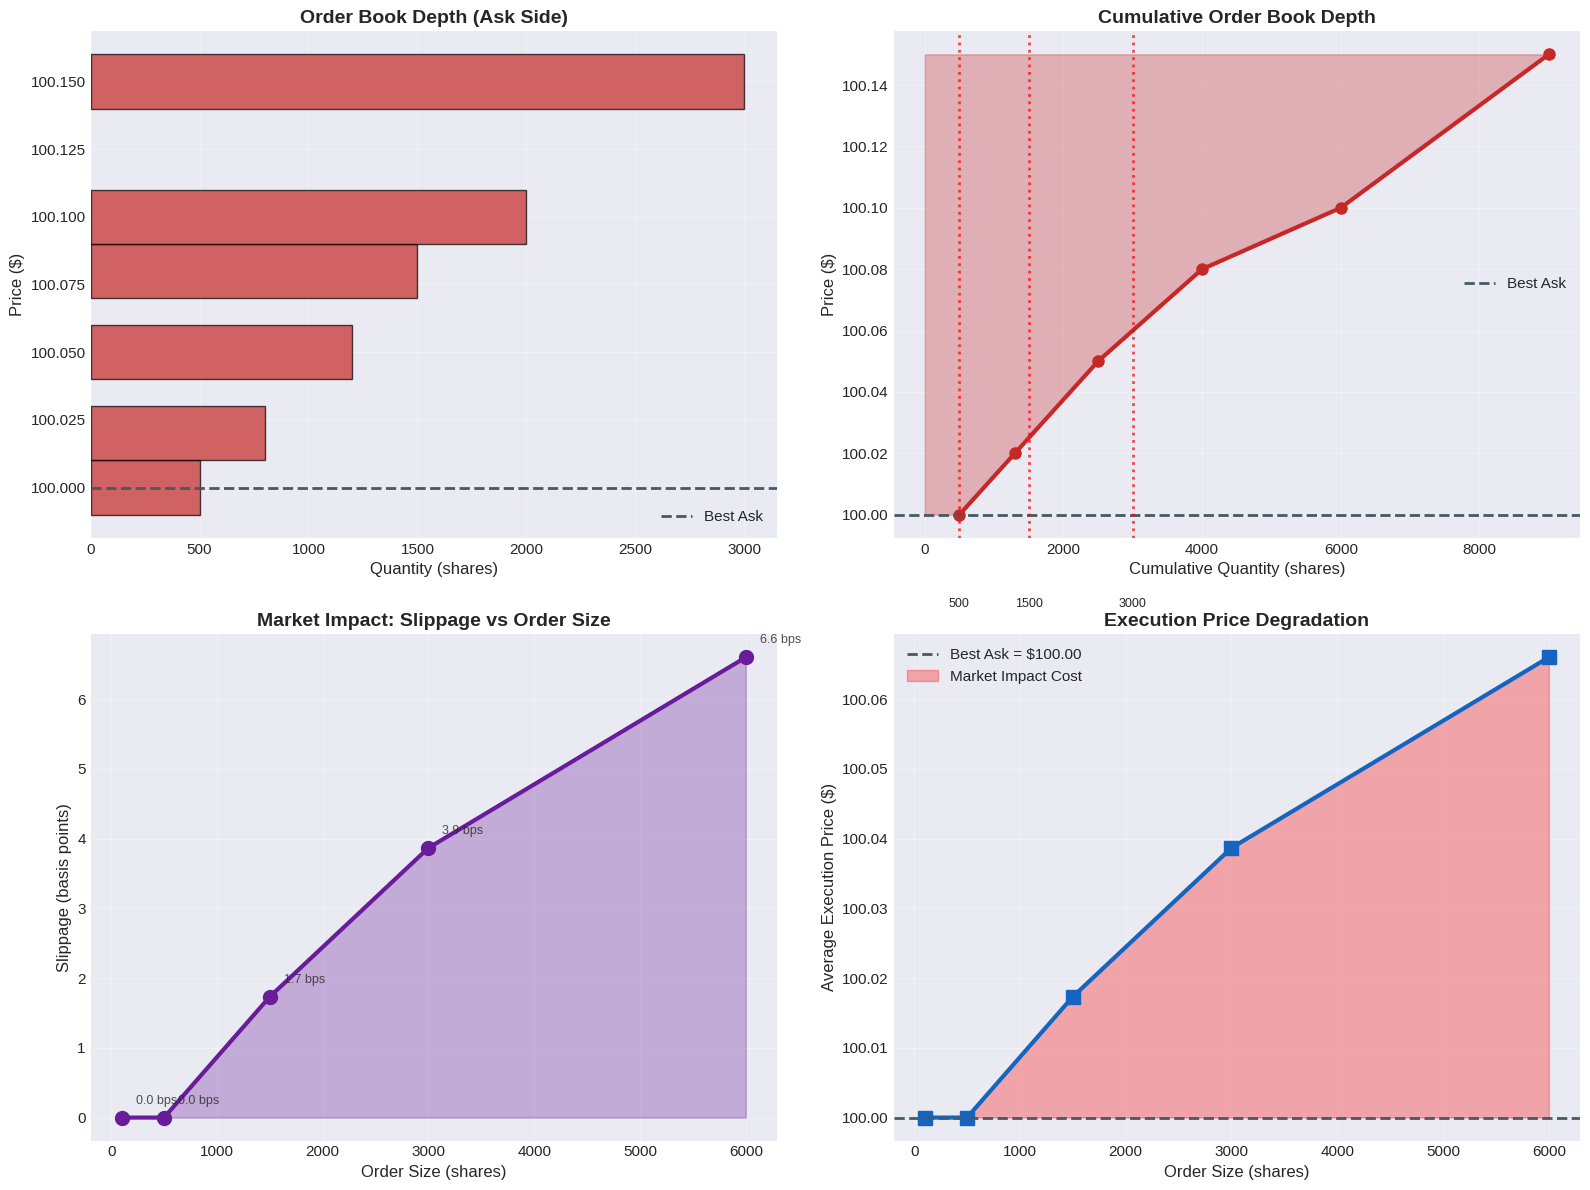


KEY INSIGHTS FROM VISUALIZATION
📊 Chart 1 (Top-Left): Shows discrete liquidity levels in the order book
📊 Chart 2 (Top-Right): Cumulative view reveals total available liquidity
📊 Chart 3 (Bottom-Left): Market impact grows non-linearly with order size
📊 Chart 4 (Bottom-Right): Larger orders pay progressively worse prices

💡 Professional traders slice large orders to minimize this impact!


In [3]:
# ========================================
# Visualizing Market Impact and Slippage
# ========================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Order Book Depth Chart
ax1 = axes[0, 0]
prices = [level[0] for level in ask_book]
quantities = [level[1] for level in ask_book]
cumulative_qty = np.cumsum(quantities)

ax1.barh(prices, quantities, height=0.02, color=COLORS['ask'], alpha=0.7, edgecolor='black')
ax1.axhline(ask_book[0][0], color=COLORS['neutral'], linestyle='--', linewidth=2, label='Best Ask')
ax1.set_xlabel('Quantity (shares)', fontsize=12)
ax1.set_ylabel('Price ($)', fontsize=12)
ax1.set_title('Order Book Depth (Ask Side)', fontweight='bold', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Cumulative Depth Chart
ax2 = axes[0, 1]
ax2.plot(cumulative_qty, prices, marker='o', linewidth=3, color=COLORS['ask'], markersize=8)
ax2.fill_betweenx(prices, 0, cumulative_qty, alpha=0.3, color=COLORS['ask'])
ax2.axhline(ask_book[0][0], color=COLORS['neutral'], linestyle='--', linewidth=2, label='Best Ask')

# Mark example order sizes
for size in [500, 1500, 3000]:
    if size <= cumulative_qty[-1]:
        idx = np.searchsorted(cumulative_qty, size)
        if idx < len(prices):
            ax2.axvline(size, color='red', linestyle=':', alpha=0.7)
            ax2.text(size, prices[0] - 0.03, f'{size}', ha='center', fontsize=9)

ax2.set_xlabel('Cumulative Quantity (shares)', fontsize=12)
ax2.set_ylabel('Price ($)', fontsize=12)
ax2.set_title('Cumulative Order Book Depth', fontweight='bold', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Slippage vs Order Size
ax3 = axes[1, 0]
ax3.plot(results_df['Order Size'], results_df['Slippage (bps)'], 
         marker='o', linewidth=3, markersize=10, color=COLORS['impact'])
ax3.fill_between(results_df['Order Size'], 0, results_df['Slippage (bps)'], 
                 alpha=0.3, color=COLORS['impact'])
ax3.set_xlabel('Order Size (shares)', fontsize=12)
ax3.set_ylabel('Slippage (basis points)', fontsize=12)
ax3.set_title('Market Impact: Slippage vs Order Size', fontweight='bold', fontsize=14)
ax3.grid(True, alpha=0.3)

# Add annotations
for idx, row in results_df.iterrows():
    ax3.annotate(f"{row['Slippage (bps)']:.1f} bps", 
                xy=(row['Order Size'], row['Slippage (bps)']),
                xytext=(10, 10), textcoords='offset points',
                fontsize=9, alpha=0.8)

# 4. Average Execution Price vs Order Size
ax4 = axes[1, 1]
ax4.plot(results_df['Order Size'], results_df['Avg Price'], 
         marker='s', linewidth=3, markersize=10, color=COLORS['trade'])
ax4.axhline(ask_book[0][0], color=COLORS['neutral'], linestyle='--', 
           linewidth=2, label=f'Best Ask = ${ask_book[0][0]:.2f}')
ax4.fill_between(results_df['Order Size'], ask_book[0][0], results_df['Avg Price'], 
                 alpha=0.3, color='red', label='Market Impact Cost')
ax4.set_xlabel('Order Size (shares)', fontsize=12)
ax4.set_ylabel('Average Execution Price ($)', fontsize=12)
ax4.set_title('Execution Price Degradation', fontweight='bold', fontsize=14)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("KEY INSIGHTS FROM VISUALIZATION")
print("="*80)
print("📊 Chart 1 (Top-Left): Shows discrete liquidity levels in the order book")
print("📊 Chart 2 (Top-Right): Cumulative view reveals total available liquidity")
print("📊 Chart 3 (Bottom-Left): Market impact grows non-linearly with order size")
print("📊 Chart 4 (Bottom-Right): Larger orders pay progressively worse prices")
print("\n💡 Professional traders slice large orders to minimize this impact!")

---

## 2. Order Book Structure and Price Formation

### 2.1 The Limit Order Book: A Competitive Queue

The **limit order book** is the heart of modern electronic markets. It is a real-time database of all resting limit orders, organized by price and time priority. On one side are the **bids** (buy orders), arranged in descending price order—highest bid at the top. On the other side are the **asks** (sell orders), arranged in ascending price order—lowest ask at the top. The difference between the highest bid and the lowest ask is the **bid-ask spread**, which represents the cost of immediate execution. The order book is not just data; it is a dynamic competitive equilibrium where liquidity providers and takers continuously negotiate prices through their order placement and cancellation decisions.

Understanding order book dynamics is essential because the book reveals **where liquidity exists and where it doesn't**. A deep order book with many resting orders at each price level can absorb large trades without significant price impact. A thin order book with sparse liquidity will see prices gap dramatically when large orders arrive. Professional traders read the order book like a poker player reads tells: Are the large orders real or fake? Are they strategic placements to manipulate perception? How quickly do cancelled orders get replaced? The order book is also the foundation for market making—liquidity providers place bids and asks simultaneously, earning the spread while managing inventory risk. High-frequency traders build sophisticated models of order book dynamics, predicting short-term price movements based on the imbalance between buy and sell pressure at different price levels.

### 2.2 Price-Time Priority: The Matching Engine's Rules

Most exchanges use **price-time priority** (also called FIFO - First In, First Out) for order matching. Orders are first prioritized by price: a buy order at $100.00 has priority over a buy order at $99.99. Among orders at the same price level, they are prioritized by arrival time: the first order to arrive is the first to be filled. This seems simple, but it creates profound strategic implications. If you want to ensure your order fills, you can place it one tick better than existing orders ("pennying"), jumping to the front of the queue. But if everyone does this, the spread widens and liquidity fragments across multiple price levels. The race for queue position has driven the arms race in trading speed—high-frequency traders invest millions in low-latency infrastructure to gain microseconds of time advantage.

Alternative matching rules exist in some markets. **Pro-rata matching** allocates fills proportionally based on order size rather than arrival time, which benefits larger liquidity providers. **Time-weighted matching** gives priority to orders that have been resting longer, discouraging rapid-fire order cancellations. Dark pools often use different rules entirely, such as **midpoint matching** where trades execute at the midpoint between the bid and ask rather than at the quoted prices. Understanding the matching rules of your trading venue is critical because they determine your execution probability and the strategies available to you. Some high-frequency strategies are specifically designed to exploit the quirks of particular matching engines, such as placing and cancelling orders rapidly to probe for hidden liquidity or to manipulate queue positions.

### 2.3 Order Book Imbalance and Price Prediction

The **order book imbalance** measures the relative pressure from buyers versus sellers. A simple measure is:

$$\text{Imbalance} = \frac{\text{Bid Volume} - \text{Ask Volume}}{\text{Bid Volume} + \text{Ask Volume}}$$

An imbalance close to +1 indicates strong buying pressure; close to -1 indicates selling pressure. Researchers have found that order book imbalance has **predictive power for short-term price movements**. When bid volume significantly exceeds ask volume, the price is more likely to move up in the next few seconds or minutes. This makes intuitive sense: if many people want to buy and few want to sell, the price should rise to clear the market. However, the predictive relationship is not perfect because order book data can be misleading—large orders can be fake (placed with intent to cancel), and hidden iceberg orders don't appear in the visible book.

More sophisticated measures of order book imbalance incorporate **depth at multiple price levels** and **order flow toxicity**. The insight is that not all orders are equally informative. A large bid that appears suddenly might be an informed trader, or it might be a high-frequency trader providing liquidity. The key is to distinguish between "toxic" order flow (from informed traders who will adversely select you) and "benign" order flow (from noise traders or liquidity providers). Advanced microstructure models build this distinction using machine learning on order flow patterns, order sizes, and the identity (when available) of the counterparties. Market makers use these models to adjust their quotes dynamically—widening spreads when they detect toxic order flow and tightening spreads when they sense benign flow. This creates an information arms race where each side tries to hide their true intentions while inferring the intentions of others.

---

### Mathematical Framework for Order Books

**Mid-Price**:

$$P_{\text{mid}} = \frac{P_{\text{bid}} + P_{\text{ask}}}{2}$$

**Order Book Imbalance** (at level $k$):

$$I_k = \frac{V_{\text{bid}}^{(k)} - V_{\text{ask}}^{(k)}}{V_{\text{bid}}^{(k)} + V_{\text{ask}}^{(k)}}$$

**Weighted Imbalance** (considering multiple levels):

$$I = \sum_{k=1}^{K} w_k \cdot I_k, \quad \text{where } \sum_{k=1}^{K} w_k = 1$$

**Microprice** (volume-weighted mid-price):

$$P_{\text{micro}} = \frac{V_{\text{ask}} \cdot P_{\text{bid}} + V_{\text{bid}} \cdot P_{\text{ask}}}{V_{\text{bid}} + V_{\text{ask}}}$$

In [4]:
# ========================================
# Order Book Simulation
# ========================================

class OrderBook:
    """Simple limit order book implementation."""
    
    def __init__(self):
        self.bids = {}  # price -> total quantity
        self.asks = {}  # price -> total quantity
        self.bid_queue = {}  # price -> list of (order_id, quantity)
        self.ask_queue = {}  # price -> list of (order_id, quantity)
        
    def add_order(self, order: Order) -> None:
        """Add a limit order to the book."""
        if order.price is None:
            raise ValueError("Limit orders must have a price")
        
        if order.side == OrderSide.BUY:
            self.bids[order.price] = self.bids.get(order.price, 0) + order.quantity
            if order.price not in self.bid_queue:
                self.bid_queue[order.price] = []
            self.bid_queue[order.price].append((order.order_id, order.quantity))
        else:
            self.asks[order.price] = self.asks.get(order.price, 0) + order.quantity
            if order.price not in self.ask_queue:
                self.ask_queue[order.price] = []
            self.ask_queue[order.price].append((order.order_id, order.quantity))
    
    def get_best_bid(self) -> Optional[float]:
        """Get highest bid price."""
        return max(self.bids.keys()) if self.bids else None
    
    def get_best_ask(self) -> Optional[float]:
        """Get lowest ask price."""
        return min(self.asks.keys()) if self.asks else None
    
    def get_spread(self) -> Optional[float]:
        """Calculate bid-ask spread."""
        best_bid = self.get_best_bid()
        best_ask = self.get_best_ask()
        if best_bid is not None and best_ask is not None:
            return best_ask - best_bid
        return None
    
    def get_mid_price(self) -> Optional[float]:
        """Calculate mid-price."""
        best_bid = self.get_best_bid()
        best_ask = self.get_best_ask()
        if best_bid is not None and best_ask is not None:
            return (best_bid + best_ask) / 2
        return None
    
    def get_book_imbalance(self, depth: int = 5) -> float:
        """
        Calculate order book imbalance.
        
        Returns value between -1 (sell pressure) and +1 (buy pressure).
        """
        sorted_bids = sorted(self.bids.items(), reverse=True)[:depth]
        sorted_asks = sorted(self.asks.items())[:depth]
        
        total_bid_vol = sum(qty for _, qty in sorted_bids)
        total_ask_vol = sum(qty for _, qty in sorted_asks)
        
        if total_bid_vol + total_ask_vol == 0:
            return 0.0
        
        return (total_bid_vol - total_ask_vol) / (total_bid_vol + total_ask_vol)
    
    def get_depth_data(self, levels: int = 10) -> Dict[str, List[Tuple[float, int]]]:
        """Get order book depth data for visualization."""
        sorted_bids = sorted(self.bids.items(), reverse=True)[:levels]
        sorted_asks = sorted(self.asks.items())[:levels]
        
        return {
            'bids': sorted_bids,
            'asks': sorted_asks
        }


# Create and populate a sample order book
print("="*80)
print("ORDER BOOK CONSTRUCTION")
print("="*80)

book = OrderBook()

# Add buy orders (bids)
bid_orders = [
    (99.95, 1000),
    (99.94, 1500),
    (99.93, 800),
    (99.92, 2000),
    (99.90, 2500),
    (99.88, 1200),
    (99.85, 3000),
]

# Add sell orders (asks)
ask_orders = [
    (100.00, 900),
    (100.02, 1200),
    (100.03, 700),
    (100.05, 1800),
    (100.08, 2200),
    (100.10, 1500),
    (100.15, 2800),
]

order_id = 0
for price, qty in bid_orders:
    order = Order(
        order_id=order_id,
        order_type=OrderType.LIMIT,
        side=OrderSide.BUY,
        quantity=qty,
        price=price
    )
    book.add_order(order)
    order_id += 1

for price, qty in ask_orders:
    order = Order(
        order_id=order_id,
        order_type=OrderType.LIMIT,
        side=OrderSide.SELL,
        quantity=qty,
        price=price
    )
    book.add_order(order)
    order_id += 1

# Display book statistics
print(f"Best Bid: ${book.get_best_bid():.2f}")
print(f"Best Ask: ${book.get_best_ask():.2f}")
print(f"Bid-Ask Spread: ${book.get_spread():.2f}")
print(f"Mid-Price: ${book.get_mid_price():.2f}")
print(f"Order Book Imbalance: {book.get_book_imbalance():.4f}")
print("\n💡 Negative imbalance indicates more selling pressure than buying pressure")

ORDER BOOK CONSTRUCTION
Best Bid: $99.95
Best Ask: $100.00
Bid-Ask Spread: $0.05
Mid-Price: $99.97
Order Book Imbalance: 0.0685

💡 Negative imbalance indicates more selling pressure than buying pressure


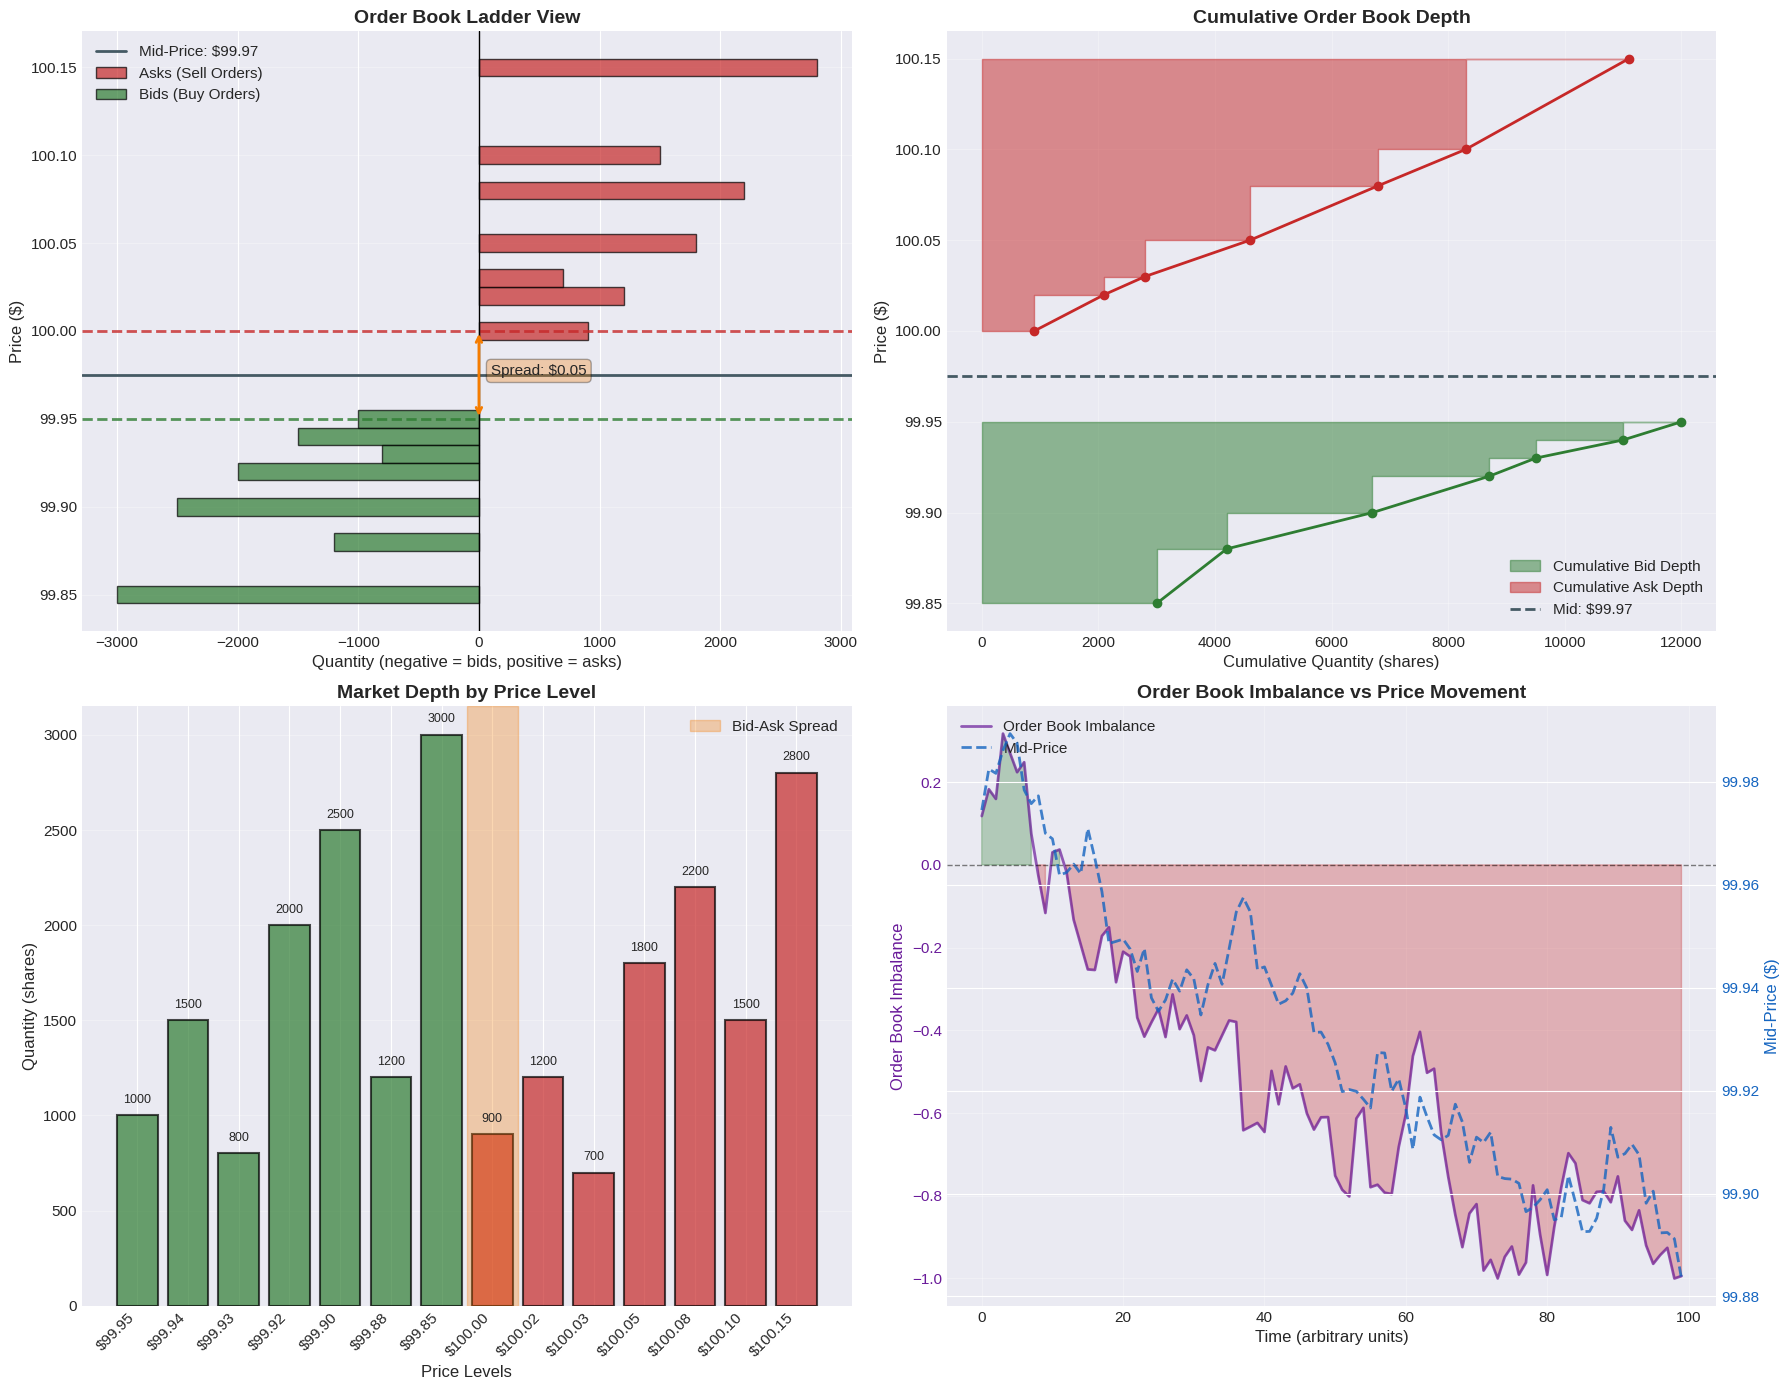


VISUALIZATION INSIGHTS
📊 Chart 1: Ladder view shows order book symmetry and spread
📊 Chart 2: Cumulative depth reveals total available liquidity
📊 Chart 3: Histogram shows liquidity distribution across price levels
📊 Chart 4: Demonstrates correlation between imbalance and price movement

💡 Order book imbalance is a leading indicator of short-term price direction!


In [5]:
# ========================================
# Order Book Visualization
# ========================================

depth_data = book.get_depth_data(levels=10)
bids = depth_data['bids']
asks = depth_data['asks']

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Traditional Order Book Ladder View
ax1 = axes[0, 0]

# Plot asks
ask_prices = [p for p, q in asks]
ask_quantities = [q for p, q in asks]
ax1.barh(ask_prices, ask_quantities, height=0.01, color=COLORS['ask'], 
         alpha=0.7, edgecolor='black', label='Asks (Sell Orders)')

# Plot bids
bid_prices = [p for p, q in bids]
bid_quantities = [-q for p, q in bids]  # Negative for left side
ax1.barh(bid_prices, bid_quantities, height=0.01, color=COLORS['bid'], 
         alpha=0.7, edgecolor='black', label='Bids (Buy Orders)')

# Mark spread
best_bid = book.get_best_bid()
best_ask = book.get_best_ask()
ax1.axhline(best_bid, color=COLORS['bid'], linestyle='--', linewidth=2, alpha=0.8)
ax1.axhline(best_ask, color=COLORS['ask'], linestyle='--', linewidth=2, alpha=0.8)
ax1.axhline(book.get_mid_price(), color=COLORS['neutral'], linestyle='-', 
           linewidth=2, label=f'Mid-Price: ${book.get_mid_price():.2f}')

# Add spread annotation
ax1.annotate('', xy=(0, best_ask), xytext=(0, best_bid),
            arrowprops=dict(arrowstyle='<->', color=COLORS['spread'], lw=2))
ax1.text(100, (best_bid + best_ask) / 2, 
        f'Spread: ${book.get_spread():.2f}',
        fontsize=11, ha='left', 
        bbox=dict(boxstyle='round', facecolor=COLORS['spread'], alpha=0.3))

ax1.set_xlabel('Quantity (negative = bids, positive = asks)', fontsize=12)
ax1.set_ylabel('Price ($)', fontsize=12)
ax1.set_title('Order Book Ladder View', fontweight='bold', fontsize=14)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3, axis='y')
ax1.axvline(0, color='black', linewidth=1)

# 2. Cumulative Depth Chart
ax2 = axes[0, 1]

# Calculate cumulative quantities
bid_cum = np.cumsum([q for p, q in reversed(bids)])
bid_prices_rev = [p for p, q in reversed(bids)]
ask_cum = np.cumsum([q for p, q in asks])

# Plot cumulative depth
ax2.fill_betweenx(bid_prices_rev, 0, bid_cum, alpha=0.5, color=COLORS['bid'], 
                  step='post', label='Cumulative Bid Depth')
ax2.fill_betweenx(ask_prices, 0, ask_cum, alpha=0.5, color=COLORS['ask'], 
                  step='post', label='Cumulative Ask Depth')

ax2.plot(bid_cum, bid_prices_rev, color=COLORS['bid'], linewidth=2, marker='o', markersize=6)
ax2.plot(ask_cum, ask_prices, color=COLORS['ask'], linewidth=2, marker='o', markersize=6)

ax2.axhline(book.get_mid_price(), color=COLORS['neutral'], linestyle='--', 
           linewidth=2, label=f'Mid: ${book.get_mid_price():.2f}')

ax2.set_xlabel('Cumulative Quantity (shares)', fontsize=12)
ax2.set_ylabel('Price ($)', fontsize=12)
ax2.set_title('Cumulative Order Book Depth', fontweight='bold', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Market Depth Histogram
ax3 = axes[1, 0]

# Combine bid and ask data
all_prices = bid_prices + ask_prices
all_quantities = [q for p, q in bids] + [q for p, q in asks]
colors = [COLORS['bid']] * len(bids) + [COLORS['ask']] * len(asks)

bars = ax3.bar(range(len(all_prices)), all_quantities, color=colors, 
              alpha=0.7, edgecolor='black', linewidth=1.5)

# Customize x-axis labels
ax3.set_xticks(range(len(all_prices)))
ax3.set_xticklabels([f'${p:.2f}' for p in all_prices], rotation=45, ha='right')

# Add value labels on bars
for i, (bar, qty) in enumerate(zip(bars, all_quantities)):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 50,
            f'{int(qty)}', ha='center', va='bottom', fontsize=9)

# Mark the spread region
spread_start = len(bids) - 0.5
spread_end = len(bids) + 0.5
ax3.axvspan(spread_start, spread_end, alpha=0.3, color=COLORS['spread'], 
           label='Bid-Ask Spread')

ax3.set_xlabel('Price Levels', fontsize=12)
ax3.set_ylabel('Quantity (shares)', fontsize=12)
ax3.set_title('Market Depth by Price Level', fontweight='bold', fontsize=14)
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# 4. Order Book Imbalance Over Time (Simulation)
ax4 = axes[1, 1]

# Simulate book imbalance changes
np.random.seed(42)
time_steps = 100
imbalances = []
mid_prices = []

current_imbalance = book.get_book_imbalance()
current_mid = book.get_mid_price()

for t in range(time_steps):
    # Random walk for imbalance
    current_imbalance += np.random.normal(0, 0.1)
    current_imbalance = np.clip(current_imbalance, -1, 1)
    
    # Price moves in direction of imbalance
    current_mid += current_imbalance * 0.002 + np.random.normal(0, 0.005)
    
    imbalances.append(current_imbalance)
    mid_prices.append(current_mid)

# Create twin axis
ax4_twin = ax4.twinx()

# Plot imbalance
line1 = ax4.plot(imbalances, color=COLORS['impact'], linewidth=2, 
                label='Order Book Imbalance', alpha=0.7)
ax4.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax4.fill_between(range(time_steps), 0, imbalances, 
                where=np.array(imbalances) > 0, alpha=0.3, 
                color=COLORS['bid'], label='Buy Pressure')
ax4.fill_between(range(time_steps), 0, imbalances, 
                where=np.array(imbalances) < 0, alpha=0.3, 
                color=COLORS['ask'], label='Sell Pressure')

# Plot price on secondary axis
line2 = ax4_twin.plot(mid_prices, color=COLORS['trade'], linewidth=2, 
                     linestyle='--', label='Mid-Price', alpha=0.8)

ax4.set_xlabel('Time (arbitrary units)', fontsize=12)
ax4.set_ylabel('Order Book Imbalance', fontsize=12, color=COLORS['impact'])
ax4_twin.set_ylabel('Mid-Price ($)', fontsize=12, color=COLORS['trade'])
ax4.set_title('Order Book Imbalance vs Price Movement', fontweight='bold', fontsize=14)

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax4.legend(lines, labels, loc='upper left')
ax4.grid(True, alpha=0.3)

ax4.tick_params(axis='y', labelcolor=COLORS['impact'])
ax4_twin.tick_params(axis='y', labelcolor=COLORS['trade'])

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("VISUALIZATION INSIGHTS")
print("="*80)
print("📊 Chart 1: Ladder view shows order book symmetry and spread")
print("📊 Chart 2: Cumulative depth reveals total available liquidity")
print("📊 Chart 3: Histogram shows liquidity distribution across price levels")
print("📊 Chart 4: Demonstrates correlation between imbalance and price movement")
print("\n💡 Order book imbalance is a leading indicator of short-term price direction!")